## Representation Learning with a Simple Autoencoder (MNIST)

An autoencoder learns to compress its input into a low-dimensional code and
reconstruct it back out -- no labels involved. Squeezing everything needed to
rebuild a 784-pixel digit through a 32-dimensional bottleneck forces the
network to discover which factors of variation actually matter (stroke
shape, thickness, slant) rather than memorizing raw pixels. That compressed
code is a *learned representation*, and it turns out to be useful well
beyond reconstruction.

We build the architecture below, train it purely as a reconstruction task on
unlabeled MNIST digits, then in the second half of the notebook put the
learned representation to work: freeze the encoder, attach a small
classification head, and train that head on a tiny handful of labeled
examples -- to see how much of the classification problem the unsupervised
pretraining already solved.

| Layer | Output shape | Notes |
| --- | --- | --- |
| Input | 784 | Flattened 28x28 digit |
| Dense (encoder) | 128 | ReLU |
| Dense (encoder) | 32 | ReLU -- the bottleneck code $h$ |
| Dense (decoder) | 128 | ReLU |
| Dense (decoder) | 784 | Sigmoid -- pixels in $[0, 1]$ |

Symmetric encoder/decoder is a common convention, not a requirement.

### 1. Setup

Standard imports, seed, and device -- same conventions as the rest of this series.

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")
print("device:", device)

device: cpu


### 2. Dataset: MNIST

28x28 grayscale handwritten digits, 10 classes, 60k train / 10k test images.

In [2]:
# Download the raw MNIST archives directly from torchvision's S3 mirror into data/,
# before loading them with torchvision. wget's -nc (no-clobber) flag skips the download
# if a file is already present, so re-running this cell will not re-download the data.
DATA_URL = "https://ossci-datasets.s3.amazonaws.com/mnist"
RAW_DIR = "data/MNIST/raw"

!mkdir -p {RAW_DIR}
!wget -nc -nv -P {RAW_DIR} {DATA_URL}/train-images-idx3-ubyte.gz
!wget -nc -nv -P {RAW_DIR} {DATA_URL}/train-labels-idx1-ubyte.gz
!wget -nc -nv -P {RAW_DIR} {DATA_URL}/t10k-images-idx3-ubyte.gz
!wget -nc -nv -P {RAW_DIR} {DATA_URL}/t10k-labels-idx1-ubyte.gz

In [3]:
transform = transforms.ToTensor()  # scales pixels to [0, 1], shape (1, 28, 28)

# download=True only extracts here: the archives were already fetched by wget above
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print(f"train images: {len(train_ds)}, test images: {len(test_ds)}, image shape: {train_ds[0][0].shape}")

train images: 60000, test images: 10000, image shape: torch.Size([1, 28, 28])


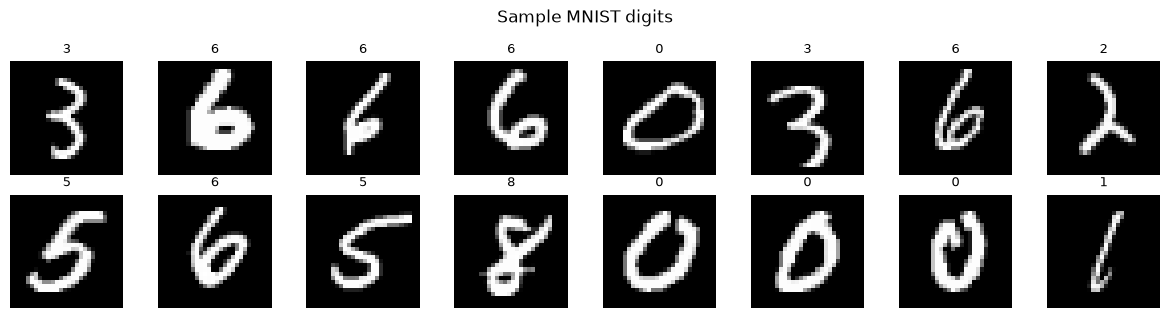

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
sample_idx = np.random.RandomState(0).choice(len(train_ds), size=16, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    img, label = train_ds[idx]
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(str(label), fontsize=9)
    ax.axis("off")
fig.suptitle("Sample MNIST digits")
plt.tight_layout()
plt.show()

### 3. The autoencoder

Encoder and decoder are separate modules, each a plain `nn.Sequential`, so
the encoder can be lifted out and reused on its own later in this notebook.
`Autoencoder` just chains them and also returns the bottleneck code `h`,
used for the representation-visualization step below.

In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, h):
        return self.net(h).view(-1, 1, 28, 28)


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        return x_hat, h

### 4. Loss function and training utilities

Reconstruction-only loss: binary cross-entropy between the sigmoid output
and the $[0, 1]$ pixel targets, the standard pairing for autoencoders with a
sigmoid decoder. No labels appear anywhere in this loop.

In [6]:
def train_autoencoder(model, loader, epochs, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    history = {"step_loss": []}
    for epoch in range(epochs):
        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, _ in loader:  # labels unused: purely unsupervised reconstruction
            xb = xb.to(device)
            optimizer.zero_grad()
            x_hat, _ = model(xb)
            loss = criterion(x_hat, xb)
            loss.backward()
            optimizer.step()

            history["step_loss"].append(loss.item())
            running_loss += loss.item()
            n_batches += 1

        print(f"  epoch {epoch + 1}/{epochs}  train_loss={running_loss / n_batches:.4f}")
    return history


@torch.no_grad()
def evaluate_reconstruction(model, loader):
    model.eval()
    criterion = nn.BCELoss()
    total_loss, n_batches = 0.0, 0
    for xb, _ in loader:
        xb = xb.to(device)
        x_hat, _ = model(xb)
        total_loss += criterion(x_hat, xb).item()
        n_batches += 1
    return total_loss / n_batches

### 5. Experiment 1: train the autoencoder

10 epochs, Adam, purely on the unlabeled training images.

In [7]:
EPOCHS_AE = 10

torch.manual_seed(0)
autoencoder = Autoencoder()
print("Training autoencoder (unsupervised, reconstruction only)...")
ae_history = train_autoencoder(autoencoder, train_loader, epochs=EPOCHS_AE)

test_recon_loss = evaluate_reconstruction(autoencoder, test_loader)
print(f"test reconstruction loss: {test_recon_loss:.4f}")

Training autoencoder (unsupervised, reconstruction only)...


  epoch 1/10  train_loss=0.2150


  epoch 2/10  train_loss=0.1322


  epoch 3/10  train_loss=0.1153


  epoch 4/10  train_loss=0.1080


...

  epoch 7/10  train_loss=0.0987


  epoch 8/10  train_loss=0.0972


  epoch 9/10  train_loss=0.0961


  epoch 10/10  train_loss=0.0952


test reconstruction loss: 0.0934


### 6. Reconstruction quality

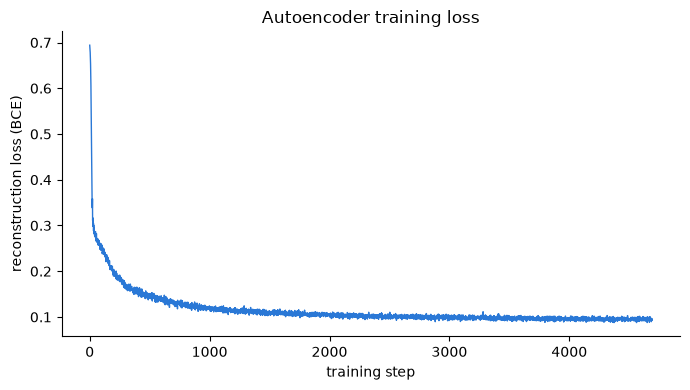

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ae_history["step_loss"], color="#2a78d6", linewidth=1)
ax.set_xlabel("training step")
ax.set_ylabel("reconstruction loss (BCE)")
ax.set_title("Autoencoder training loss")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

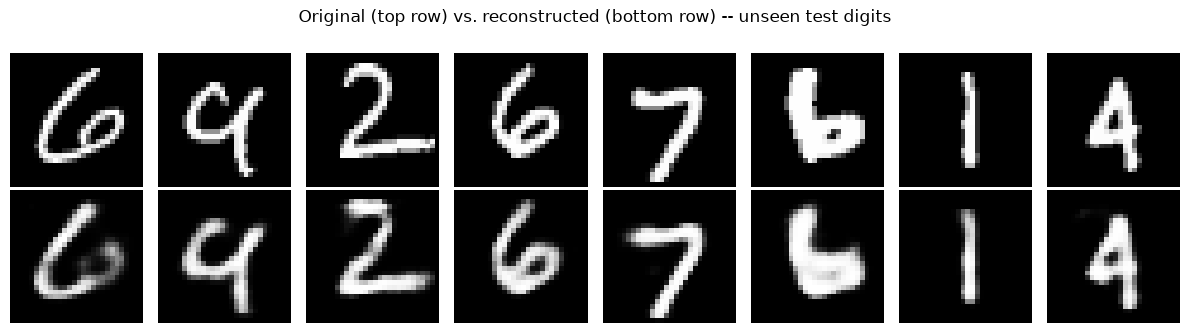

In [9]:
autoencoder.eval()
sample_idx = np.random.RandomState(1).choice(len(test_ds), size=8, replace=False)
originals = torch.stack([test_ds[i][0] for i in sample_idx]).to(device)
with torch.no_grad():
    reconstructions, _ = autoencoder(originals)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(originals[i].squeeze(0).cpu(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i].squeeze(0).cpu(), cmap="gray")
    axes[1, i].axis("off")
fig.suptitle("Original (top row) vs. reconstructed (bottom row) -- unseen test digits")
plt.tight_layout()
plt.show()

The bottleneck (32 numbers, versus 784 raw pixels) keeps enough to
rebuild recognizable digits -- some fine stroke detail is smoothed away, but
digit identity survives compression to about 4% of the original size.

### 7. Visualizing the learned representation

Labels are used here only to color points -- never for training. If the
digits cluster by identity in the 2-D projection, the encoder discovered
class-relevant structure without ever being told the classes.

running t-SNE on the 32-d bottleneck codes...


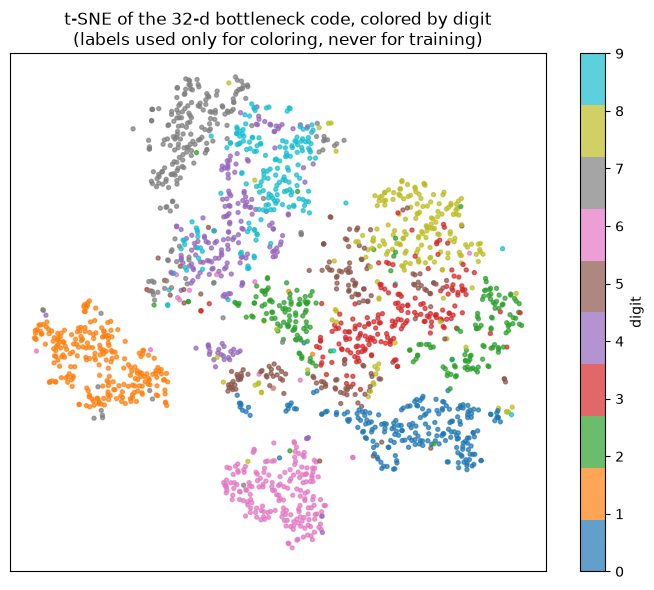

In [10]:
autoencoder.eval()
n_embed = 2000
embed_idx = np.random.RandomState(2).choice(len(test_ds), size=n_embed, replace=False)
embed_x = torch.stack([test_ds[i][0] for i in embed_idx]).to(device)
embed_y = np.array([test_ds[i][1] for i in embed_idx])

with torch.no_grad():
    codes = autoencoder.encoder(embed_x).cpu().numpy()

print("running t-SNE on the 32-d bottleneck codes...")
codes_2d = TSNE(n_components=2, random_state=0, init="pca", perplexity=30).fit_transform(codes)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(codes_2d[:, 0], codes_2d[:, 1], c=embed_y, cmap="tab10", s=8, alpha=0.7)
cbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("digit")
ax.set_title("t-SNE of the 32-d bottleneck code, colored by digit\n(labels used only for coloring, never for training)")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

Distinct digit clusters emerge even though the encoder was trained
with a single objective -- reconstruct the pixels -- and never saw a label.
That structure is exactly what the next section puts to use.

### 8. Putting the representation to work: classification with few labels

The encoder above never saw a single label. Now we test how useful its 32-d
code is for classification when labeled data is scarce -- the situation
representation learning is meant for: a large pile of unlabeled data plus a
small labeled set.

Two models, evaluated the same way, differing only in the input
representation:

- **Frozen encoder + linear head** -- the pretrained encoder's weights are
  frozen; only a `Linear(32, 10)` head is trained on the small labeled
  subset.
- **Trained from scratch** -- the identical architecture
  (`784 -> 128 -> 32 -> 10`, all `ReLU`), but every weight is randomly
  initialized and trained end-to-end on the same small labeled subset -- no
  pretraining, no unlabeled data involved at all.

Both are evaluated on the full 10k-image test set. We sweep the number of
labeled examples per class from 1 up to 100.

In [11]:
train_targets = train_ds.targets.numpy()

def sample_labeled_subset(dataset, targets, n_per_class, seed):
    rng = np.random.RandomState(seed)
    idx = np.concatenate([
        rng.choice(np.where(targets == c)[0], size=n_per_class, replace=False)
        for c in range(10)
    ])
    rng.shuffle(idx)
    X = torch.stack([dataset[i][0] for i in idx])
    y = torch.tensor([dataset[i][1] for i in idx])
    return X, y


class FrozenEncoderClassifier(nn.Module):
    # pretrained, frozen encoder (784 -> 128 -> 32) + a trainable linear head
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.head = nn.Linear(32, 10)

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.head(h)


class ScratchClassifier(nn.Module):
    # same shape as encoder + head, but randomly initialized and fully trainable
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_full_batch(model, params, X, y, epochs, lr):
    # full-batch training: the few-shot subsets here are at most 1,000 images
    model.to(device)
    X, y = X.to(device), y.to(device)
    optimizer = torch.optim.Adam(params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
    return loss.item()


@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total

In [12]:
N_PER_CLASS = [1, 2, 5, 10, 20, 50, 100]
EPOCHS_FEW_SHOT = 300
LR_FEW_SHOT = 1e-2

acc_frozen, acc_scratch = [], []
for n in N_PER_CLASS:
    X, y = sample_labeled_subset(train_ds, train_targets, n, seed=0)

    torch.manual_seed(0)
    frozen_model = FrozenEncoderClassifier(copy.deepcopy(autoencoder.encoder))
    train_full_batch(frozen_model, frozen_model.head.parameters(), X, y,
                      epochs=EPOCHS_FEW_SHOT, lr=LR_FEW_SHOT)
    acc_frozen.append(eval_accuracy(frozen_model, test_loader))

    torch.manual_seed(0)
    scratch_model = ScratchClassifier()
    train_full_batch(scratch_model, scratch_model.parameters(), X, y,
                      epochs=EPOCHS_FEW_SHOT, lr=LR_FEW_SHOT)
    acc_scratch.append(eval_accuracy(scratch_model, test_loader))

    print(f"{n:>4} labeled/class ({10 * n:>4} total): "
          f"frozen encoder+linear head acc={acc_frozen[-1]:.4f}   "
          f"scratch (same arch) acc={acc_scratch[-1]:.4f}")

   1 labeled/class (  10 total): frozen encoder+linear head acc=0.3579   scratch (same arch) acc=0.2660


   2 labeled/class (  20 total): frozen encoder+linear head acc=0.4790   scratch (same arch) acc=0.4834


   5 labeled/class (  50 total): frozen encoder+linear head acc=0.7133   scratch (same arch) acc=0.6236


  10 labeled/class ( 100 total): frozen encoder+linear head acc=0.7599   scratch (same arch) acc=0.7054


  20 labeled/class ( 200 total): frozen encoder+linear head acc=0.8008   scratch (same arch) acc=0.7846


  50 labeled/class ( 500 total): frozen encoder+linear head acc=0.8488   scratch (same arch) acc=0.8683


 100 labeled/class (1000 total): frozen encoder+linear head acc=0.8707   scratch (same arch) acc=0.8976


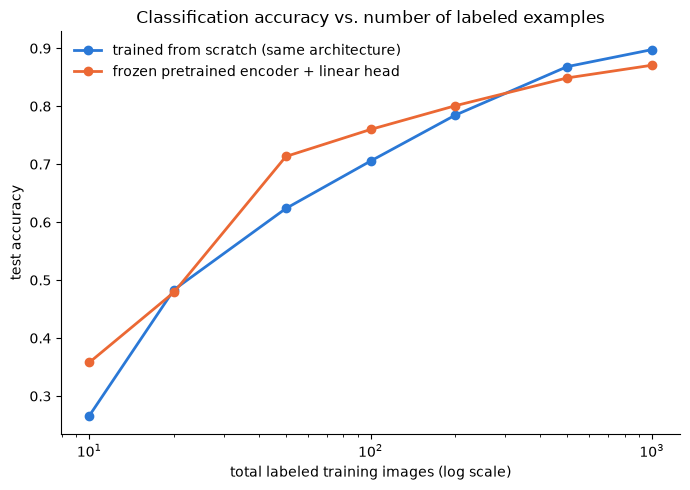

In [13]:
total_labels = [10 * n for n in N_PER_CLASS]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(total_labels, acc_scratch, color="#2a78d6", marker="o", linewidth=2,
        label="trained from scratch (same architecture)")
ax.plot(total_labels, acc_frozen, color="#eb6834", marker="o", linewidth=2,
        label="frozen pretrained encoder + linear head")
ax.set_xscale("log")
ax.set_xlabel("total labeled training images (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("Classification accuracy vs. number of labeled examples")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

With only a handful of labels per class, the frozen pretrained
encoder gives the linear head a big head start: the reconstruction
objective already pulled same-digit codes close together (Section 7), so a
*linear* boundary on top of it goes a long way. The from-scratch network has
to learn both a useful representation and a classifier from the same tiny
labeled set, and with so little supervision it struggles to do either well.
As the labeled set grows, the from-scratch model catches up -- eventually it
has enough supervision to learn its own good features -- but the gap at the
low end is exactly the case unsupervised pretraining is for: plentiful
unlabeled data, scarce labels.

### Conclusion

- An autoencoder trained with **no labels at all**, purely to reconstruct
  its own input through a narrow bottleneck, learns a compressed code that
  already separates digits by identity (Section 7).
- That learned representation is a **transferable asset**: a linear
  classifier on top of the frozen, pretrained code substantially
  outperforms a same-sized network trained end-to-end when labels are
  scarce (Section 8).
- The gain is largest exactly where it matters most in practice -- when
  unlabeled data is abundant but labeled data is expensive or limited.